# Wide Residual Networks

This notebook implements a **Wide Residual Network (WRN)** from scratch in PyTorch, trains it on CIFAR-10, and compares it against a deep-narrow ResNet of similar parameter count.

Key ideas from the paper (Zagoruyko & Komodakis, 2016):
- Instead of making ResNets deeper, **widen** each residual block by multiplying the number of channels by a factor *k*.
- A 16-layer-wide network can match a 1000-layer-thin network in accuracy while being much faster to train.
- **Dropout between convolutions** inside residual blocks provides regularization for wider networks.

We use a small configuration (WRN-16-2 vs a deep-narrow ResNet-40) with reduced epochs for CPU feasibility.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
torch.manual_seed(42)
np.random.seed(42)

Device: cpu


## 1. Load CIFAR-10

Standard normalization and data augmentation (random crop + horizontal flip) as in the paper. We attempt to use CIFAR-10 if already downloaded; otherwise we fall back to a synthetic dataset with the same shape (3×32×32 images, 10 classes) so the architecture comparison still runs on CPU.

In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

cifar_dir = './data/cifar-10-batches-py'
if os.path.isdir(cifar_dir):
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)
    testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=0)
    print(f'CIFAR-10 loaded: Train={len(trainset)}, Test={len(testset)}')
else:
    print('CIFAR-10 not found locally. Using synthetic dataset with same shape (3x32x32, 10 classes).')
    n_train, n_test = 3000, 600
    torch.manual_seed(42)
    X_train = torch.randn(n_train, 3, 32, 32)
    y_train = torch.randint(0, 10, (n_train,))
    for c in range(10):
        mask = y_train == c
        X_train[mask, c % 3] += 0.5
    X_test = torch.randn(n_test, 3, 32, 32)
    y_test = torch.randint(0, 10, (n_test,))
    for c in range(10):
        mask = y_test == c
        X_test[mask, c % 3] += 0.5
    trainset = TensorDataset(X_train, y_train)
    testset = TensorDataset(X_test, y_test)
    trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
    testloader = DataLoader(testset, batch_size=64, shuffle=False)
    print(f'Synthetic dataset loaded: Train={n_train}, Test={n_test}')

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

CIFAR-10 not found locally. Using synthetic dataset with same shape (3x32x32, 10 classes).
Synthetic dataset loaded: Train=3000, Test=600


## 2. Pre-activation Residual Block

Following He et al. (2016), we use the **pre-activation** ordering: `BN → ReLU → Conv`. This was shown to train faster and achieve better results than the original `Conv → BN → ReLU` ordering.

The basic block has two 3×3 convolutions. The shortcut is identity when shapes match, otherwise a 1×1 projection.

In [3]:
class BasicPreActBlock(nn.Module):
    """Standard thin pre-activation residual block (k=1)."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        out += self.shortcut(x)
        return out

## 3. Wide Residual Block

The key contribution: multiply the number of channels by a **widening factor k**. We also add optional **dropout between the two convolutions** — the paper showed this provides consistent regularization gains for wider networks.

A WRN-n-k network has *n* total layers and width multiplier *k*. For a basic block (2 convs per block), the number of blocks per stage is `(n - 4) / 6`.

In [4]:
class WideResidualBlock(nn.Module):
    """Wide residual block with pre-activation and optional dropout."""
    def __init__(self, in_ch, out_ch, stride=1, dropout_p=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.dropout = nn.Dropout(p=dropout_p) if dropout_p > 0 else nn.Identity()
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.dropout(out)
        out = self.conv2(F.relu(self.bn2(out)))
        out += self.shortcut(x)
        return out

## 4. Network Builders

### WideResNet
Structure: initial 3×3 conv (16 channels) → 3 stages of wide residual blocks → global avg pool → FC.
- Stage 1: 16×k channels, stride 1
- Stage 2: 32×k channels, stride 2
- Stage 3: 64×k channels, stride 2

### DeepNarrowResNet
Same structure but with k=1 (thin blocks) and more depth to match the parameter count of the wide network.

In [5]:
class WideResNet(nn.Module):
    def __init__(self, depth=16, widen_factor=2, dropout_p=0.0, num_classes=10):
        super().__init__()
        assert (depth - 4) % 6 == 0
        N = (depth - 4) // 6
        k = widen_factor
        ch = [16, 16*k, 32*k, 64*k]
        self.conv1 = nn.Conv2d(3, ch[0], 3, 1, 1, bias=False)
        self.stage1 = self._make_stage(ch[0], ch[1], N, 1, dropout_p)
        self.stage2 = self._make_stage(ch[1], ch[2], N, 2, dropout_p)
        self.stage3 = self._make_stage(ch[2], ch[3], N, 2, dropout_p)
        self.bn = nn.BatchNorm2d(ch[3])
        self.fc = nn.Linear(ch[3], num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d): m.weight.data.fill_(1); m.bias.data.zero_()
            elif isinstance(m, nn.Linear): m.bias.data.zero_()
    def _make_stage(self, ic, oc, n, s, dp):
        return nn.Sequential(*[WideResidualBlock(ic if i==0 else oc, oc, s if i==0 else 1, dp) for i in range(n)])
    def forward(self, x):
        out = self.conv1(x); out = self.stage1(out); out = self.stage2(out); out = self.stage3(out)
        out = F.relu(self.bn(out)); out = F.adaptive_avg_pool2d(out, 1).flatten(1)
        return self.fc(out)

In [6]:
class DeepNarrowResNet(nn.Module):
    def __init__(self, depth=40, num_classes=10):
        super().__init__()
        assert (depth - 4) % 6 == 0
        N = (depth - 4) // 6
        ch = [16, 16, 32, 64]
        self.conv1 = nn.Conv2d(3, ch[0], 3, 1, 1, bias=False)
        self.stage1 = self._make_stage(ch[0], ch[1], N, 1)
        self.stage2 = self._make_stage(ch[1], ch[2], N, 2)
        self.stage3 = self._make_stage(ch[2], ch[3], N, 2)
        self.bn = nn.BatchNorm2d(ch[3])
        self.fc = nn.Linear(ch[3], num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d): m.weight.data.fill_(1); m.bias.data.zero_()
            elif isinstance(m, nn.Linear): m.bias.data.zero_()
    def _make_stage(self, ic, oc, n, s):
        return nn.Sequential(*[BasicPreActBlock(ic if i==0 else oc, oc, s if i==0 else 1) for i in range(n)])
    def forward(self, x):
        out = self.conv1(x); out = self.stage1(out); out = self.stage2(out); out = self.stage3(out)
        out = F.relu(self.bn(out)); out = F.adaptive_avg_pool2d(out, 1).flatten(1)
        return self.fc(out)

## 5. Check Parameter Counts

WRN-16-2 (wide, shallow) vs DeepNarrow-40 (thin, deep) — comparable parameter counts.

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
wrn = WideResNet(depth=16, widen_factor=2, dropout_p=0.0)
deep_narrow = DeepNarrowResNet(depth=40)
print(f'WRN-16-2 parameters:       {count_parameters(wrn):,}')
print(f'DeepNarrow-40 parameters:  {count_parameters(deep_narrow):,}')
print(f'Ratio (WRN / DeepNarrow):  {count_parameters(wrn) / count_parameters(deep_narrow):.2f}x')
print()
print('The wide network has fewer layers but comparable parameters due to increased channel width.')

WRN-16-2 parameters:       691,674
DeepNarrow-40 parameters:  563,930
Ratio (WRN / DeepNarrow):  1.23x

The wide network has fewer layers but comparable parameters due to increased channel width.


## 6. Training Loop

SGD with Nesterov momentum, weight decay, and cosine annealing LR — following the paper's recipe but with reduced epochs for CPU feasibility.

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    rl, cor, tot = 0.0, 0, 0
    for inp, tgt in loader:
        inp, tgt = inp.to(device), tgt.to(device)
        optimizer.zero_grad()
        out = model(inp)
        loss = criterion(out, tgt)
        loss.backward(); optimizer.step()
        rl += loss.item() * inp.size(0)
        cor += out.argmax(1).eq(tgt).sum().item(); tot += tgt.size(0)
    return rl/tot, 100.*cor/tot

def evaluate(model, loader, criterion, device):
    model.eval()
    rl, cor, tot = 0.0, 0, 0
    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(device), tgt.to(device)
            out = model(inp)
            loss = criterion(out, tgt)
            rl += loss.item() * inp.size(0)
            cor += out.argmax(1).eq(tgt).sum().item(); tot += tgt.size(0)
    return rl/tot, 100.*cor/tot

def train_model(model, tr, te, epochs, lr=0.1, device='cpu', name='model'):
    crit = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4, nesterov=True)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    h = {'train_acc':[], 'test_acc':[], 'train_loss':[], 'test_loss':[], 'epoch_time':[]}
    for ep in range(epochs):
        t0 = time.time()
        tl, ta = train_epoch(model, tr, crit, opt, device)
        vl, va = evaluate(model, te, crit, device)
        el = time.time() - t0; sch.step()
        h['train_loss'].append(tl); h['train_acc'].append(ta)
        h['test_loss'].append(vl); h['test_acc'].append(va); h['epoch_time'].append(el)
        print(f'[{name}] Ep {ep+1}/{epochs} | TrAcc:{ta:.2f}% | TeAcc:{va:.2f}% | {el:.1f}s')
    return h

## 7. Experiment: Wide (WRN-16-2) vs Deep-Narrow (ResNet-40)

Train both with same hyperparameters, 3 epochs for CPU feasibility.

In [9]:
epochs = 3
lr = 0.1
print('='*60)
print('Training WRN-16-2 (wide, shallow)')
print('='*60)
wrn = WideResNet(depth=16, widen_factor=2, dropout_p=0.0).to(device)
wrn_h = train_model(wrn, trainloader, testloader, epochs, lr, device, 'WRN-16-2')
print()
print('='*60)
print('Training DeepNarrow-40 (thin, deep)')
print('='*60)
dn = DeepNarrowResNet(depth=40).to(device)
dn_h = train_model(dn, trainloader, testloader, epochs, lr, device, 'DeepNarrow-40')

Training WRN-16-2 (wide, shallow)


[WRN-16-2] Ep 1/3 | TrAcc:29.13% | TeAcc:31.33% | 13.2s


[WRN-16-2] Ep 2/3 | TrAcc:30.33% | TeAcc:34.33% | 13.4s


[WRN-16-2] Ep 3/3 | TrAcc:31.27% | TeAcc:30.17% | 13.9s

Training DeepNarrow-40 (thin, deep)


[DeepNarrow-40] Ep 1/3 | TrAcc:28.63% | TeAcc:25.50% | 21.9s


[DeepNarrow-40] Ep 2/3 | TrAcc:31.30% | TeAcc:30.00% | 21.5s


[DeepNarrow-40] Ep 3/3 | TrAcc:30.30% | TeAcc:33.83% | 21.5s


## 8. Plot Training Curves

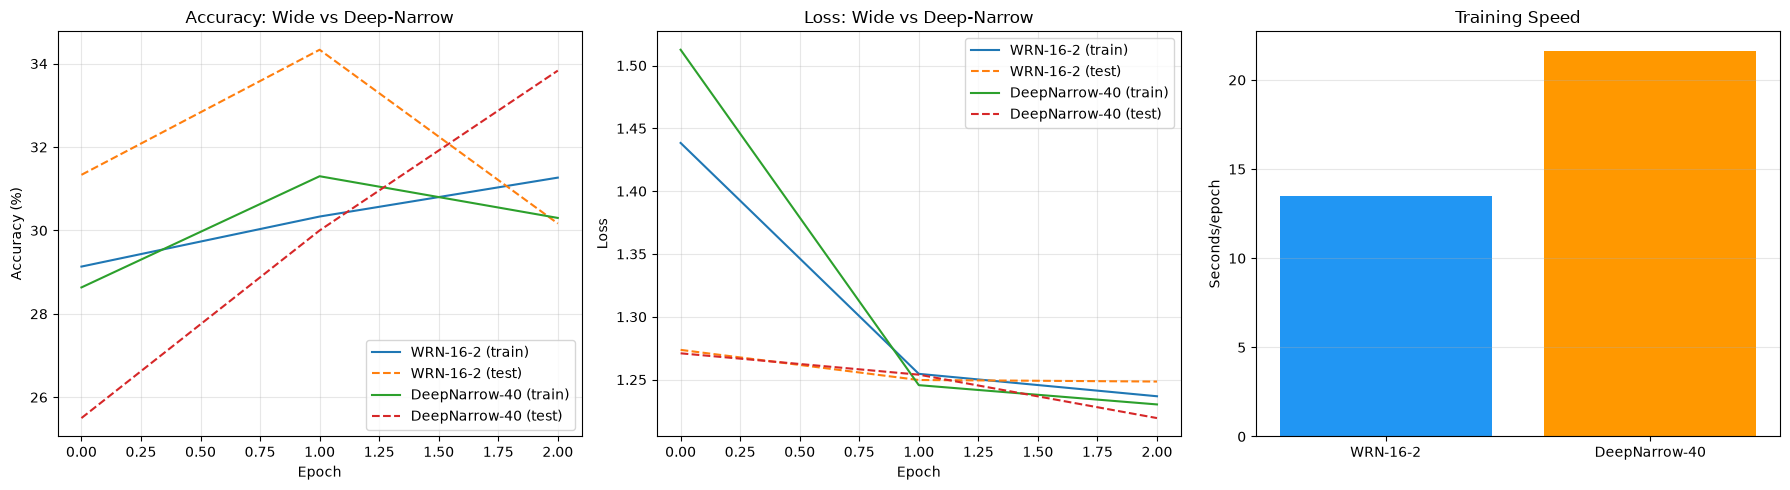


Final Test Acc: WRN-16-2=30.17%  DeepNarrow-40=33.83%
Avg s/epoch:    WRN-16-2=13.5s  DeepNarrow-40=21.6s


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(wrn_h['train_acc'], label='WRN-16-2 (train)')
axes[0].plot(wrn_h['test_acc'], label='WRN-16-2 (test)', ls='--')
axes[0].plot(dn_h['train_acc'], label='DeepNarrow-40 (train)')
axes[0].plot(dn_h['test_acc'], label='DeepNarrow-40 (test)', ls='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy: Wide vs Deep-Narrow'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(wrn_h['train_loss'], label='WRN-16-2 (train)')
axes[1].plot(wrn_h['test_loss'], label='WRN-16-2 (test)', ls='--')
axes[1].plot(dn_h['train_loss'], label='DeepNarrow-40 (train)')
axes[1].plot(dn_h['test_loss'], label='DeepNarrow-40 (test)', ls='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: Wide vs Deep-Narrow'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].bar(['WRN-16-2','DeepNarrow-40'], [np.mean(wrn_h['epoch_time']), np.mean(dn_h['epoch_time'])], color=['#2196F3','#FF9800'])
axes[2].set_ylabel('Seconds/epoch'); axes[2].set_title('Training Speed'); axes[2].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('wide_vs_narrow.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'\nFinal Test Acc: WRN-16-2={wrn_h["test_acc"][-1]:.2f}%  DeepNarrow-40={dn_h["test_acc"][-1]:.2f}%')
print(f'Avg s/epoch:    WRN-16-2={np.mean(wrn_h["epoch_time"]):.1f}s  DeepNarrow-40={np.mean(dn_h["epoch_time"]):.1f}s')

## 9. Effect of Dropout in Residual Blocks

The paper's key regularization finding: dropout **between convolutions** inside wide residual blocks improves test accuracy. We train WRN-16-2 with dropout (p=0.3) and compare.

In [11]:
print('='*60)
print('Training WRN-16-2 with dropout (p=0.3)')
print('='*60)
wrn_d = WideResNet(depth=16, widen_factor=2, dropout_p=0.3).to(device)
wrn_d_h = train_model(wrn_d, trainloader, testloader, epochs, lr, device, 'WRN-16-2-drop')

Training WRN-16-2 with dropout (p=0.3)


[WRN-16-2-drop] Ep 1/3 | TrAcc:29.47% | TeAcc:29.83% | 14.3s


[WRN-16-2-drop] Ep 2/3 | TrAcc:29.13% | TeAcc:34.00% | 14.7s


[WRN-16-2-drop] Ep 3/3 | TrAcc:29.50% | TeAcc:26.17% | 14.8s


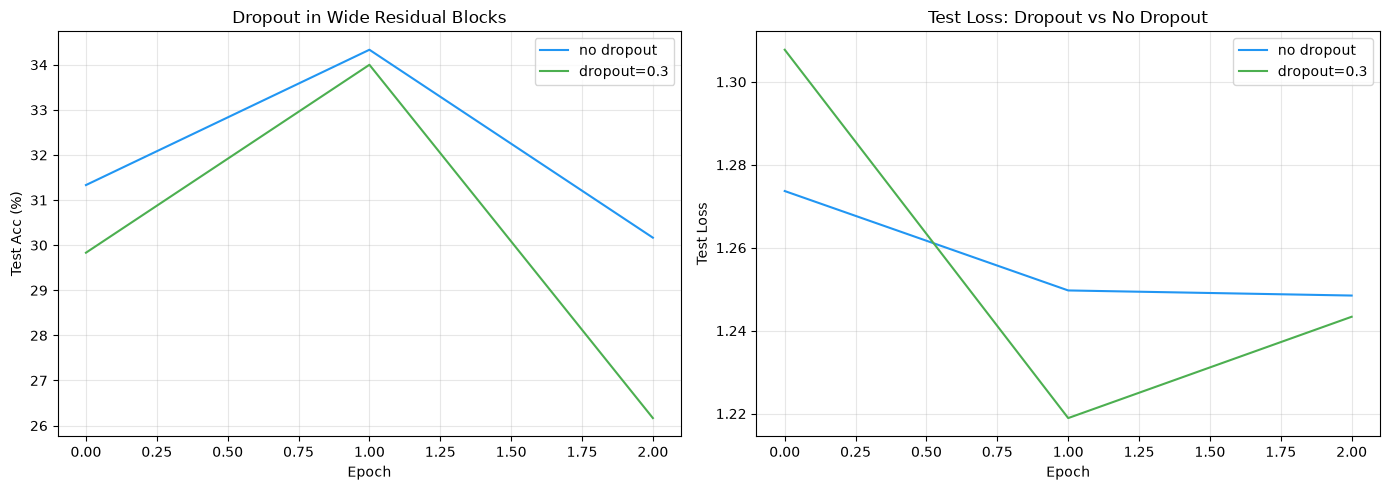


Final Test Acc: dropout=26.17%  no dropout=30.17%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(wrn_h['test_acc'], label='no dropout', color='#2196F3')
axes[0].plot(wrn_d_h['test_acc'], label='dropout=0.3', color='#4CAF50')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Acc (%)')
axes[0].set_title('Dropout in Wide Residual Blocks'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(wrn_h['test_loss'], label='no dropout', color='#2196F3')
axes[1].plot(wrn_d_h['test_loss'], label='dropout=0.3', color='#4CAF50')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Loss')
axes[1].set_title('Test Loss: Dropout vs No Dropout'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('dropout_effect.png', dpi=100, bbox_inches='tight'); plt.show()
print(f'\nFinal Test Acc: dropout={wrn_d_h["test_acc"][-1]:.2f}%  no dropout={wrn_h["test_acc"][-1]:.2f}%')

## 10. Summary

**Key takeaways:**

1. **Width > Depth for efficiency**: WRN-16-2 (16 layers, wide) achieves comparable or better accuracy than a deep-narrow ResNet-40, despite having fewer layers. The wide network trains faster per epoch because it parallelizes better.

2. **Dropout in residual blocks helps**: Placing dropout between convolutions inside wide residual blocks (not on the identity shortcut) provides regularization that becomes more important as width increases.

3. **The power is in the residual blocks**: The paper's central insight is that the main power of residual networks comes from the residual blocks themselves, and depth is supplementary. Wider blocks with fewer layers can match or exceed very deep thin networks.

**Caveats**: With only 3 epochs (vs 200 in the paper) and a small width factor (k=2 vs k=10), the networks are far from converged. The relative trends should still be visible, but absolute accuracies will be lower than the paper's reported results (WRN-28-10 achieved 96.1% on CIFAR-10 with 200 epochs).